In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
df = pd.read_csv(r'D:\Phuong\ProjectHe\HR\Employee Turnover & Attrition Analysis.csv')
df

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [31]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,MaxExperience
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,13.561395,7302.397983,0.832578,50.007651,1.648075,19.778197,20.565875
std,21519.150028,12.079673,10.471364,2151.457423,0.994991,28.466459,1.555689,11.804593,12.079673
min,1.000000,18.000000,0.000000,1316.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18580.250000,28.000000,5.000000,5658.000000,0.000000,25.000000,0.000000,10.000000,10.000000
50%,37209.500000,39.000000,11.000000,7354.000000,1.000000,50.000000,1.000000,19.000000,21.000000
75%,55876.750000,49.000000,21.000000,8880.000000,2.000000,75.000000,3.000000,30.000000,31.000000
max,74498.000000,59.000000,41.000000,16149.000000,4.000000,99.000000,6.000000,41.000000,41.000000


In [5]:
# Điều kiện không hợp lý
invalid_condition = (df['Years at Company'] > df['Age'] - 18) | (df['Company Tenure'] > df['Age'] - 18)

# Đếm số nhân viên sai
num_invalid = df[invalid_condition].shape[0]

print(f"Số nhân viên có dữ liệu không hợp lý: {num_invalid}")


Số nhân viên có dữ liệu không hợp lý: 54381


In [10]:
df_invalid = df[invalid_condition]
df_invalid[['Age', 'Years at Company', 'Company Tenure']]


,Age,Years at Company,Company Tenure
0,31,19,89
2,24,10,74
3,36,7,50
4,56,41,68
5,38,3,47
...,...,...,...
59593,50,12,35
59594,18,4,73
59595,22,14,29
59596,23,8,9


In [11]:
df['MaxExperience'] = df['Age'] - 18
df

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,MaxExperience
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed,13
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,Mid,Medium,21,No,No,No,Fair,Low,Stayed,41
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,Mid,Medium,74,No,No,No,Poor,Low,Stayed,6
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,Mid,Small,50,Yes,No,No,Good,Medium,Stayed,18
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,Senior,Medium,68,No,No,No,Fair,Medium,Stayed,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,Senior,Small,35,No,No,Yes,Poor,Very High,Left,32
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,Senior,Medium,73,No,No,No,Fair,Medium,Left,0
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,Entry,Small,29,No,Yes,No,Good,Medium,Stayed,4
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,Entry,Large,9,No,No,No,Good,Low,Left,5


In [15]:
invalid_exp = df['Years at Company'] >= df['MaxExperience']
invalid_tenure = df['Company Tenure'] >= df['MaxExperience']


In [18]:
invalid_exp.sum()

25989

In [19]:
invalid_tenure.sum()

54805

In [35]:
# Điều kiện 1: Nhân viên làm ở công ty lâu hơn tuổi - 18
cond_company = df['Years at Company'] > (df['Age'] - 18)

# Điều kiện 2: Kinh nghiệm làm việc lớn hơn số năm có thể làm
cond_experience = df['Company Tenure'] > (df['Age'] - 18)

# Tổng hợp
print("Số dòng vi phạm YearsAtCompany > Age - 18:", cond_company.sum())
print("Số dòng vi phạm YearsExperience > Age - 18:", cond_experience.sum())

# Cả hai cùng vi phạm
print("Số dòng vi phạm cả hai điều kiện:", (cond_company & cond_experience).sum())


Số dòng vi phạm YearsAtCompany > Age - 18: 0
Số dòng vi phạm YearsExperience > Age - 18: 0
Số dòng vi phạm cả hai điều kiện: 0


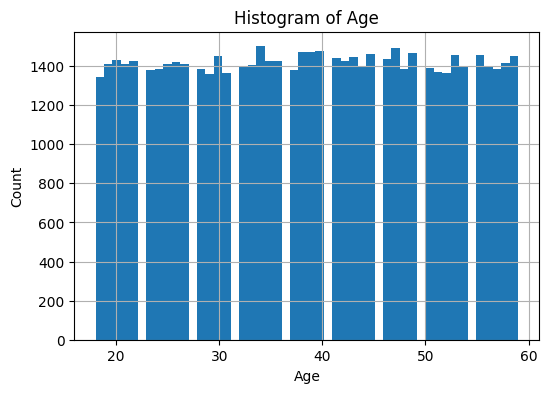

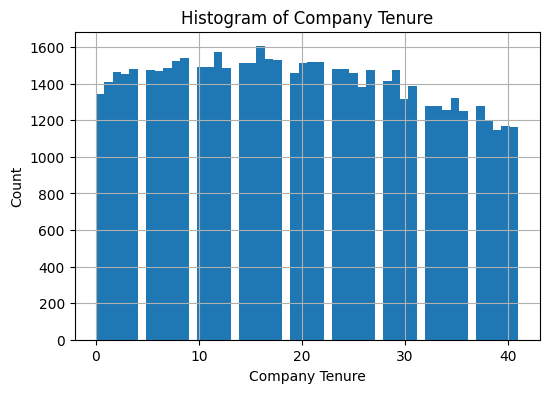

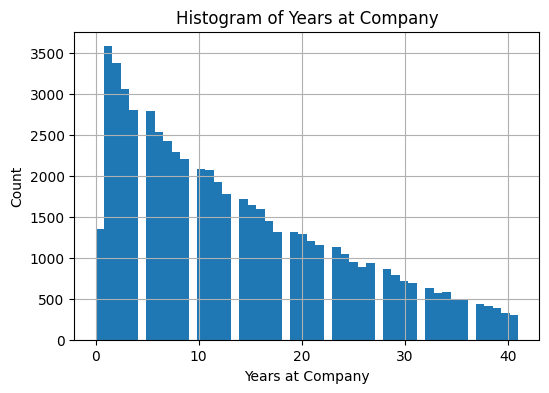

In [34]:
import matplotlib.pyplot as plt

cols = ['Age', 'Company Tenure', 'Years at Company']

for col in cols:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=50)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


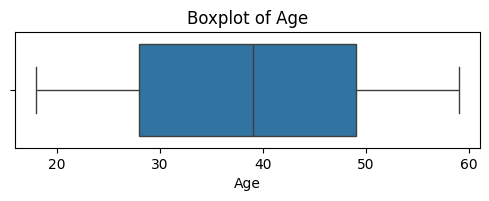

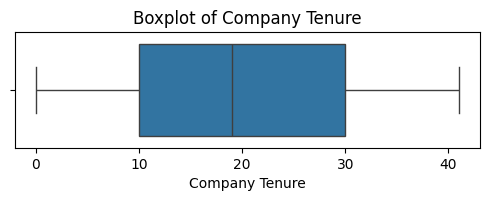

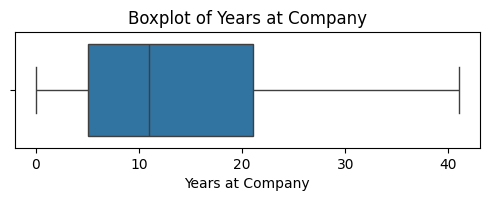

In [36]:
import seaborn as sns

for col in cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [28]:
# Giới hạn Company Tenure: Không được lớn hơn Age - 18
df['Company Tenure'] = df[['Company Tenure', 'Age']].apply(
    lambda x: min(x[0], max(x[1] - 18, 0)), axis=1
)
# Giới hạn YearsAtCompany: Không được lớn hơn Age - 18
df['Years at Company'] = df[['Years at Company', 'Age']].apply(
    lambda x: min(x[0], max(x[1] - 18, 0)), axis=1
)


C:\Users\OS\AppData\Local\Temp\ipykernel_13300\3611015685.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min(x[0], max(x[1] - 18, 0)), axis=1
C:\Users\OS\AppData\Local\Temp\ipykernel_13300\3611015685.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min(x[0], max(x[1] - 18, 0)), axis=1


In [30]:
# Kiểm tra xem còn dòng nào bất hợp lý không
invalid_condition = (df['Company Tenure'] > df['Age'] - 18) | (df['Years at Company'] > df['Age'] - 18)
print("Còn dòng lỗi sau xử lý:", invalid_condition.sum())


Còn dòng lỗi sau xử lý: 0


In [37]:
df.to_csv('HR.csv',index=False)


In [38]:
import math
import os
import random
import re
import sys

In [6]:

def is_leap(year):
    leap = False
    if year%100==0:
        if year%400==0:
            leap=True
        else:
            leap=False
    else:
        if year%4==0:
            leap=True
        else:
            leap=False
    # Write your logic here
    
    return leap

year = int(input())
print(is_leap(year))

False
